# LLM Model Integration With Langchain

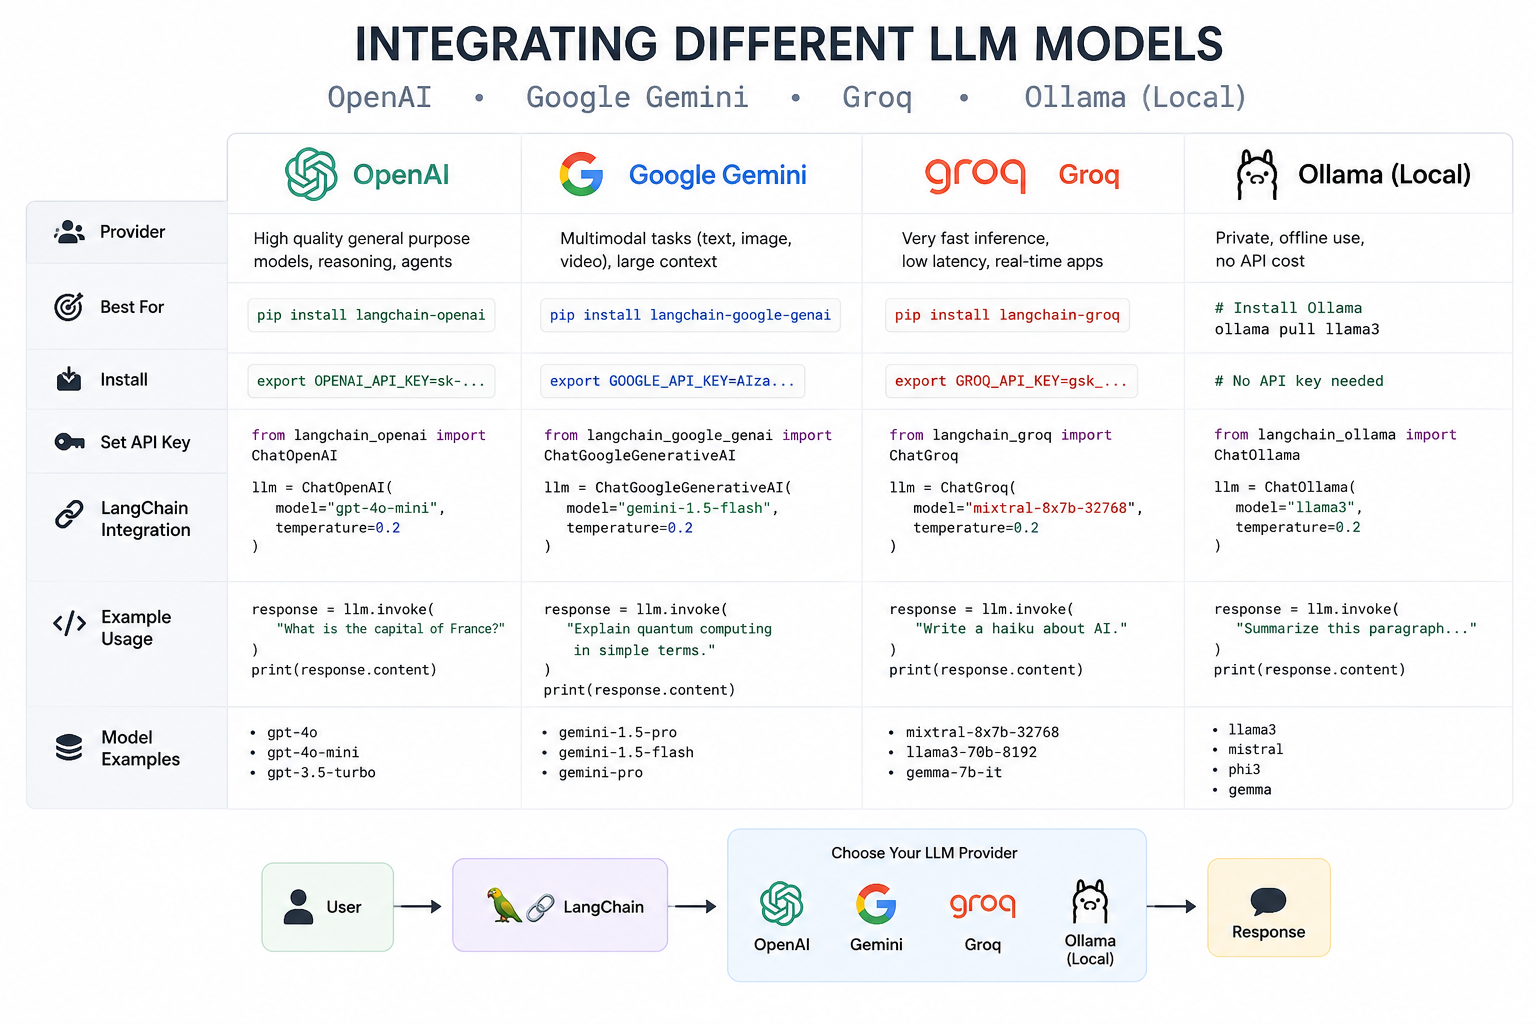

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

import openai
open_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
google_api_key = os.getenv("GOOGLE_API_KEY")


In [2]:
from langchain.chat_models import init_chat_model
model=init_chat_model("gpt-4")
model

c:\Users\Uditya\anaconda3\envs\genai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOpenAI(output_version=None, profile={'name': 'GPT-4', 'release_date': '2023-11-06', 'last_updated': '2024-04-09', 'open_weights': False, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': False, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000200CBBDB610>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000200CC539DD0>, root_client=<openai.OpenAI object at 0x00000200CBBDB190>, root_async_client=<openai.AsyncOpenAI object at 0x00000200CC539950>, model_name='gpt-4', model_kwargs={}, openai_api_ke

In [3]:
# Invoke the model
# model.invoke("Hello how are you?")

In [4]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")
response = model.invoke("why do parrots talks?")
response.content

'Parrots talk for a fascinating combination of reasons, driven by their **intelligence, social nature, and innate vocal abilities.** It\'s not just mimicry; there\'s a lot more going on!\n\nHere\'s a breakdown of why parrots talk:\n\n**1. Social Bonding and Communication:**\n\n*   **Flock Animals:** Parrots are highly social creatures that live in large flocks in the wild. They rely on constant vocalizations to maintain contact, warn of danger, locate each other, and coordinate activities within the group. Talking, or vocalizing, is their primary way of staying connected.\n*   **Reinforcing Social Bonds:** In a flock, vocalizations help strengthen bonds between individuals. Mimicking sounds can be a way to show affiliation and belonging.\n*   **Mimicry as a Social Tool:** In the wild, parrots may mimic sounds of their environment, including other animals and even natural sounds like wind or water. This can be for camouflage, to understand their surroundings, or to communicate with othe

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model ="google_genai:gemini-2.5-flash-lite")
response = model.invoke("why do parrots talks?")
response.content


In [7]:
model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("why do parrots talk")
response.content

'<think>\nOkay, so I want to figure out why parrots can talk. Let me start by recalling what I know. Parrots are known for mimicking human speech, right? But why do they do that? I think it has something to do with their vocal anatomy. Maybe they have a special structure in their throats or something. Wait, I remember hearing about the syrinx. Is that what allows them to make sounds?\n\nAlso, I\'ve heard that parrots are social animals. Maybe they talk to communicate with each other or to bond with their owners. Do they use speech as a way to interact? Or is there a more evolutionary reason, like adapting to their environment?\n\nAnother thing is that not all parrots can talk equally. Some species, like African Greys or Amazons, are better at it. Why is that? Maybe their brain structure is different. I think some parrots have higher cognitive abilities, which might help them learn and mimic human speech better.\n\nI should also consider the purpose. Do they talk just because they can, 

In [8]:
from langchain_groq import ChatGroq
model = ChatGroq(model = "qwen/qwen3-32b")
response = model.invoke("What is ai")
response

AIMessage(content='<think>\nOkay, so the user asked, "What is AI?" Hmm, let\'s think about how to approach this. First, I need to define AI clearly. Maybe start with the basics. AI stands for Artificial Intelligence. But wait, what does that actually mean? It\'s the simulation of human intelligence by machines. Right, but I should explain the key aspects.\n\nDifferent types of AI come to mind. There\'s narrow AI, which is what we have now, doing specific tasks like facial recognition or language translation. Then there\'s the more hypothetical general AI, which can handle any intellectual task a human can. But people might confuse these, so I should clarify that distinction.\n\nApplications are important to mention. AI is used in so many areas now—healthcare for diagnostics, finance for fraud detection, transportation with self-driving cars, etc. Examples make it relatable. Maybe mention some everyday AI interactions like voice assistants or recommendation systems on Netflix or Amazon.

## Streaming

In [9]:
model.invoke("write me a 200 words para on ai")

AIMessage(content="<think>\nOkay, the user wants a 200-word paragraph on AI. Let me start by defining AI in simple terms. I need to mention machine learning and neural networks since they're key components. Maybe include examples like virtual assistants and recommendation systems to make it relatable. Also, touch on different applications in healthcare, finance, etc. I should address both the benefits, like efficiency, and the challenges, such as bias and job displacement. Don't forget to mention ethical considerations and the need for responsible development. Keep the language clear and avoid jargon. Let me check the word count to make sure it's around 200. Maybe start with a strong opening sentence to grab attention. Ensure the flow is logical, moving from definition to examples, then to impacts and challenges. End with a positive note about the future if handled responsibly. Let me read through again to ensure it's concise and covers all necessary points without being too technical.

In [12]:
for chunk in model.stream("write me a 200 para on ai"):
    print(chunk.text, end="")

<think>
Okay, I need to write a 200-word paragraph about AI. Let me start by brainstorming the key points. First, what is AI? It's the simulation of human intelligence in machines, right? They use algorithms to perform tasks like learning, problem-solving, and decision-making. I should mention different types, maybe narrow AI versus general AI. Narrow AI is what's used today, like Siri or recommendation systems. General AI is the hypothetical future version that can handle any intellectual task.

Next, applications of AI. There's healthcare, where it helps with diagnostics and personalized medicine. Then there's self-driving cars, which use AI for navigation and obstacle detection. Customer service chatbots are common too. Also, AI in finance for fraud detection and algorithmic trading. Maybe mention creative fields like art and music generated by AI.

Ethical concerns are important. Job displacement is a big one, as AI automates jobs. Data privacy issues, since AI systems need lots of

## Batch

In [13]:
response = model.batch(
    [
        "Why do parrots have colorfull feather",
        "How do airplane fly",
        "what is quantum computing"
    ]
)
for re in response:
    print(re)



content="<think>\nOkay, so the user is asking why parrots have colorful feathers. Let me start by recalling what I know about parrots and their biology. Parrots are known for their vibrant colors. I remember that coloration in animals often serves multiple purposes like camouflage, communication, or attracting mates. But parrots are usually in environments where bright colors might not help with hiding, so maybe it's more about communication or sexual selection.\n\nFirst, I need to consider the different functions of colorful feathers. One possibility is sexual selection. In many bird species, males have brighter plumage to attract females. So maybe male parrots use their colors to show off to potential mates. But some parrot species are monomorphic, meaning males and females look similar, so that might not explain it all.\n\nAnother angle is that the colors could indicate health or genetic quality. Bright colors might signal good nutrition or strong immune systems. For example, carote